In [1]:
# (TBD). run a baseline GRPO + GSM8K, to understand what case got "shorten -> failed"

# "completion": "<think>\n\n</think>\n\nPancho walks 20 miles on 5 days and 10 miles on 2 days.  \nTotal = (20 \u00d7 5) + (10 \u00d7 2) = 100 + 20 = **120 miles**.", "correct": true
# Observation 1. 
# - model essentially "skip" reasoning entirely, when we enforce "length regularization"
# - Question 1. how is the answer parsed? there is no "####" yet we are still able to judge correctness? quite interesting.
# - Answer 1. the last appearing number is also treated as an answer, when #### is not present
# - Question 2. 
# - even at the start, <think>\n\n</think> is used, the actual 'CoT' appears after the deliminator, not before it
# - Answer 2. a '/no_think' is added to the end of prompt, causing defaul "<think>\n\n</think>" prepending
#            included a script with '/think' appended to prompt, to enable "thinking mode" -- expect much longer completion as a consequence here\\

# Observation 2. 
# - heavy prefix sharing is observed, and common prefix node oftenly have more failures than success, and it fails to "stay on" in the next 
#   Question 3. how does the "advantage value" get assigned to each node? with length regularization & without length regularization? 

Eval accuracy by (config, step):
step                0      100    200    300
config                                      
baseline_grpo     0.798  0.826  0.836  0.839
invlog_long_w10   0.798  0.567  0.534  0.538
invlog_short_w10  0.798  0.815  0.716  0.697
longshort_w10     0.797  0.807  0.741  0.735
predvelo_w10      0.794  0.831  0.836  0.838
traj_w10          0.795  0.810  0.806  0.803

Mean CoT length by (config, step):
step                0      100    200    300
config                                      
baseline_grpo     569.4  512.3  478.6  478.0
invlog_long_w10   569.0  840.4  863.1  865.8
invlog_short_w10  568.6  170.7   96.1   85.3
longshort_w10     568.5  169.0  117.4  110.9
predvelo_w10      571.0  487.1  472.1  470.8
traj_w10          568.9  182.3  170.7  168.3


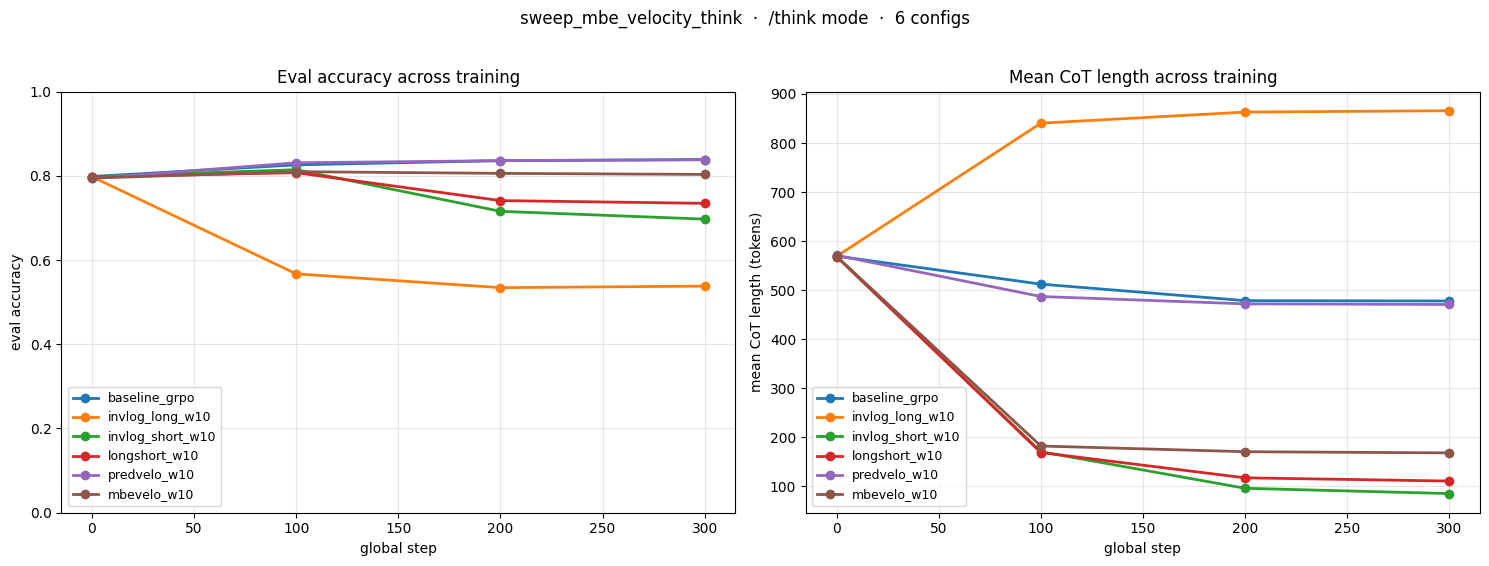

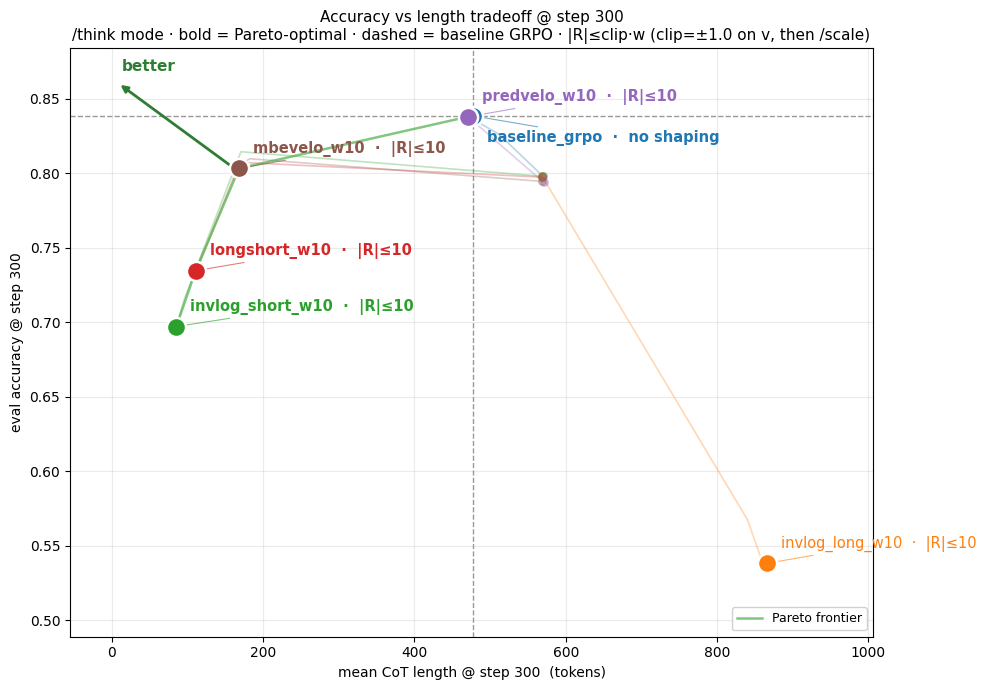

In [9]:
# Question. what are the evaluation accuracy & mean length for each config?
#
# The .log files don't record eval accuracy (FastEval path returns loss=0 and
# never computes a correctness metric), so parse it straight from each config's
# eval_rollout.jsonl. Each line = one rollout with {global_step, correct,
# n_tokens, n_cot_tokens}; aggregate to per-(config, step) accuracy & mean len.

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT = Path("/Users/fangyuanyu/Implementation/arl")
SWEEP   = PROJECT / "logs/sweep_mbe_velocity_think"

# Display-name remap: traj* → mbevelo* (the trajectory MBE-velocity reward).
def disp(name: str) -> str:
    return name.replace("traj", "mbevelo")

# Effective REWARD saturation bound per config. The reward pipeline is
#   r = clip(v, ±CLIP) / SCALE          (clip applied to raw v, THEN scaled)
# so |r| ≤ CLIP/SCALE. The sweep uses CLIP=1.0 and weight w → SCALE=±1/w, hence
# |r| ≤ CLIP·w. All shaping configs here are w=10 ⇒ bound ±10 (NOT a clip of 10
# — the literal clip is ±1.0 on v; ±10 is the post-scale ceiling).
# baseline_grpo has no shaping reward (only correctness+format).
RAW_CLIP = 1.0
def reward_bound(name: str):
    if name == "baseline_grpo":
        return None
    return RAW_CLIP * 10.0   # w=10 ⇒ |reward| ≤ clip·w = 10

rows = []
for d in sorted(SWEEP.iterdir()):
    f = d / "eval_rollout.jsonl"
    if not f.is_file():
        continue
    recs = [json.loads(l) for l in f.read_text().splitlines() if l.strip()]
    if not recs:
        continue
    g = pd.DataFrame(recs)
    for step, gs in g.groupby("global_step"):
        rows.append(dict(
            config=d.name,
            step=int(step),
            n=len(gs),
            acc=gs["correct"].mean(),
            mean_len=gs["n_cot_tokens"].mean(),
            median_len=gs["n_cot_tokens"].median(),
        ))

summary = pd.DataFrame(rows).sort_values(["config", "step"]).reset_index(drop=True)

acc_piv = summary.pivot(index="config", columns="step", values="acc")
len_piv = summary.pivot(index="config", columns="step", values="mean_len")
print("Eval accuracy by (config, step):")
print(acc_piv.round(3).to_string())
print("\nMean CoT length by (config, step):")
print(len_piv.round(1).to_string())

# --- Visualization: accuracy & length trajectories, one line per config ------
configs = acc_piv.index.tolist()
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(configs)}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
for c in configs:
    s = summary[summary.config == c]
    ax.plot(s["step"], s["acc"], "o-", lw=2, color=colors[c], label=disp(c))
ax.set_xlabel("global step"); ax.set_ylabel("eval accuracy")
ax.set_title("Eval accuracy across training")
ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(fontsize=9)

ax = axes[1]
for c in configs:
    s = summary[summary.config == c]
    ax.plot(s["step"], s["mean_len"], "o-", lw=2, color=colors[c], label=disp(c))
ax.set_xlabel("global step"); ax.set_ylabel("mean CoT length (tokens)")
ax.set_title("Mean CoT length across training")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig.suptitle(f"sweep_mbe_velocity_think  ·  /think mode  ·  {len(configs)} configs",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# --- Accuracy-vs-length tradeoff scatter (final step) ------------------------
# "Better" = up-and-left (high accuracy, short CoT). Baseline reference lines,
# a Pareto frontier, faint step-0→final trajectory tails, and leader-line labels
# (config name + reward saturation bound) so co-located points don't overprint.
final_step = summary["step"].max()
fin = summary[summary.step == final_step].copy()

BASE = "baseline_grpo"
base_acc = fin.loc[fin.config == BASE, "acc"].iloc[0] if BASE in fin.config.values else None
base_len = fin.loc[fin.config == BASE, "mean_len"].iloc[0] if BASE in fin.config.values else None

fig, ax = plt.subplots(figsize=(10, 7))

# Pareto frontier (no other point is both shorter AND more accurate).
pts = fin[["mean_len", "acc"]].values
is_pareto = [
    not any((o_ln <= ln and o_ac >= ac) and (o_ln < ln or o_ac > ac)
            for o_ln, o_ac in pts)
    for ln, ac in pts
]
fin["pareto"] = is_pareto

# Baseline reference lines.
if base_acc is not None:
    ax.axhline(base_acc, color="#999", ls="--", lw=1, zorder=1)
    ax.axvline(base_len, color="#999", ls="--", lw=1, zorder=1)

# Faint trajectory tails: step-0 → final, so direction of travel is visible.
for c in configs:
    s = summary[summary.config == c].sort_values("step")
    ax.plot(s["mean_len"], s["acc"], "-", color=colors[c], lw=1.2, alpha=0.3, zorder=2)
    ax.scatter(s["mean_len"].iloc[0], s["acc"].iloc[0], s=30, color=colors[c],
               alpha=0.35, zorder=3)  # start marker (faint)

front = fin[fin.pareto].sort_values("mean_len")
ax.plot(front["mean_len"], front["acc"], "-", color="#4daf4a", lw=1.8,
        alpha=0.7, zorder=2, label="Pareto frontier")

# Final-step points (big, white-edged).
for _, r in fin.iterrows():
    ax.scatter(r["mean_len"], r["acc"], s=190, color=colors[r["config"]],
               edgecolor="white", lw=1.8, zorder=5)

# Leader-line labels: "name  ·  |R|≤10" with vertical collision avoidance.
# |R|≤bound is the post-scale reward ceiling (clip·w), NOT the raw clip (±1.0).
order = fin.sort_values("mean_len").reset_index(drop=True)
placed_y = []
for _, r in order.iterrows():
    x, y = r["mean_len"], r["acc"]
    off_y = 14
    for py in placed_y:
        if abs(py - y) < 0.018:
            off_y = -16
    b = reward_bound(r["config"])
    bound_txt = "no shaping" if b is None else f"|R|\u2264{b:.0f}"
    label = f"{disp(r['config'])}  ·  {bound_txt}"
    ax.annotate(
        label, (x, y),
        xytext=(10, off_y), textcoords="offset points",
        fontsize=10.5, va="center", ha="left",
        fontweight="bold" if r["pareto"] else "normal",
        color=colors[r["config"]],
        arrowprops=dict(arrowstyle="-", color=colors[r["config"]],
                        lw=0.8, alpha=0.6,
                        connectionstyle="arc3,rad=0"),
    )
    placed_y.append(y if off_y > 0 else y - 0.03)

# "better" arrow cue toward up-left.
ax.annotate("", xy=(0.06, 0.94), xytext=(0.22, 0.78), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="#2e7d32", lw=2))
ax.text(0.065, 0.955, "better", transform=ax.transAxes, fontsize=11,
        color="#2e7d32", fontweight="bold", va="bottom")

ax.set_xlabel(f"mean CoT length @ step {final_step}  (tokens)")
ax.set_ylabel(f"eval accuracy @ step {final_step}")
ax.set_title(f"Accuracy vs length tradeoff @ step {final_step}\n"
             f"/think mode · bold = Pareto-optimal · dashed = baseline GRPO · "
             f"|R|\u2264clip\u00b7w (clip=\u00b11.0 on v, then /scale)",
             fontsize=11)
ax.grid(alpha=0.25, zorder=0)
ax.margins(x=0.18, y=0.15)
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
fig.tight_layout()
plt.show()


parsed 30 train log points; steps 10..300
 step  rewards/predictive_velocity/mean  rewards/predictive_velocity/std  rewards/correctness_reward/mean  reward  reward_std
   10                             7.906                            3.835                            0.812   9.056       4.269
   20                             8.359                            3.447                            0.802   9.573       3.911
   30                             8.781                            3.064                            0.852  10.072       3.483
   40                             8.988                            2.695                            0.848  10.286       3.092
   50                             9.173                            2.138                            0.886  10.517       2.492
   60                             9.281                            2.004                            0.848  10.593       2.345
   70                             9.266                            2.170    

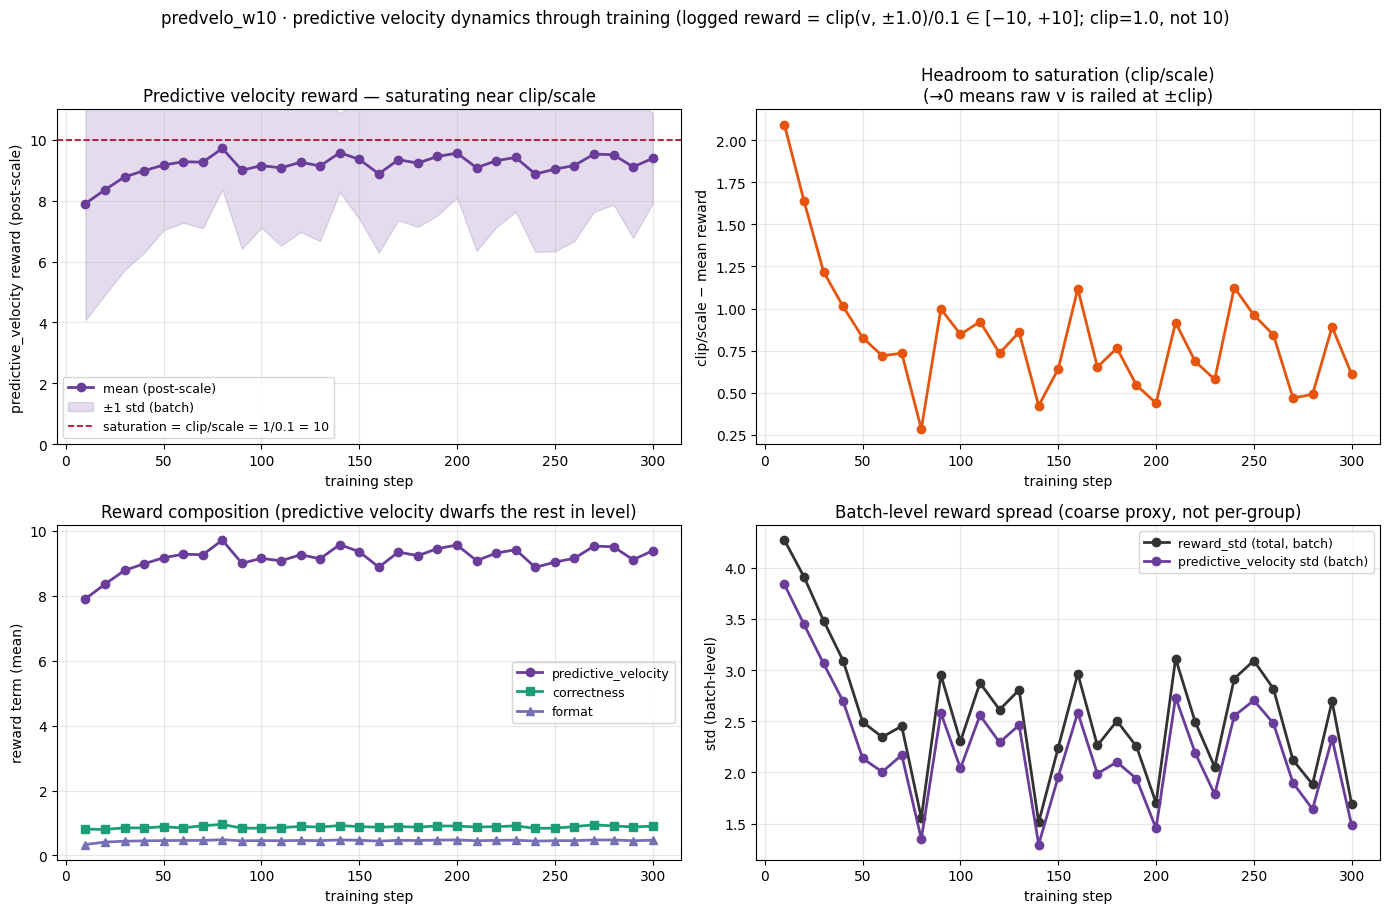

In [11]:
# Visualize the dynamics of predictive velocity through training steps.
#
# predictive_velocity is NOT in eval_rollout.jsonl — it's a TRL reward metric
# logged to train.log every `logging_steps` (=10) as
# rewards/predictive_velocity/{mean,std}. Each train log line is a python-dict
# repr starting with {'loss': ...}. Parse those, then plot the reward's
# trajectory alongside correctness and the batch-level reward spread.
#
# IMPORTANT — what TRL logs is the POST-SCALE reward:
#   r = clip(v, ±CLIP) / SCALE        (mbe_reward.py: clip THEN /scale)
# with the experiment config CLIP=1.0 (VELO_CLIP) and SCALE=0.1 (w=10 ⇒ 1/w),
# so r ∈ [-10, +10]. The dashed line below is therefore the SATURATION BOUND
# = CLIP/SCALE = 1.0/0.1 = 10 — NOT a clip of 10. The literal clip is ±1.0,
# applied to the raw value v before scaling.
#
# Caveat: TRL's rewards/*/std is the std over the *whole logged batch*
# (per_device_bs × grad_accum × num_gen rollouts), i.e. it mixes within-group
# and between-group variance. It is NOT the per-prompt-group std that GRPO
# actually normalises by — treat panel (d) as a coarse proxy only.

import ast
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path("/Users/fangyuanyu/Implementation/arl")
LOG = PROJECT / "logs/sweep_mbe_velocity_think/predvelo_w10/train.log"
LOGGING_STEPS = 10

# Grab every {'loss': ... } dict. They contain no nested braces, so a greedy
# match up to the next '}' is safe.
text = LOG.read_text()
dicts = re.findall(r"\{'loss':.*?\}", text)
recs = []
for d in dicts:
    try:
        recs.append(ast.literal_eval(d))
    except (ValueError, SyntaxError):
        continue

log = pd.DataFrame(recs)
log["step"] = (log.index + 1) * LOGGING_STEPS   # 10, 20, ..., 300

pv_mean = "rewards/predictive_velocity/mean"
pv_std  = "rewards/predictive_velocity/std"
print(f"parsed {len(log)} train log points; steps {log.step.min()}..{log.step.max()}")
print(log[["step", pv_mean, pv_std, "rewards/correctness_reward/mean",
           "reward", "reward_std"]].round(3).to_string(index=False))

# Saturation bound of the logged (post-scale) reward = CLIP / SCALE.
RAW_CLIP = 1.0    # VELO_CLIP / --predictive_velocity_clip
SCALE    = 0.1    # 1/w, w=10  (--predictive_velocity_scale 0.1)
SAT_CEIL = RAW_CLIP / SCALE   # = 10.0 (post-scale ceiling, NOT the clip)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) predictive velocity reward: mean ± std, with the saturation bound.
ax = axes[0, 0]
ax.plot(log.step, log[pv_mean], "o-", color="#6a3d9a", lw=2, label="mean (post-scale)")
ax.fill_between(log.step, log[pv_mean] - log[pv_std], log[pv_mean] + log[pv_std],
                color="#6a3d9a", alpha=0.18, label="±1 std (batch)")
ax.axhline(SAT_CEIL, color="#b00020", ls="--", lw=1.2,
           label=f"saturation = clip/scale = {RAW_CLIP:.0f}/{SCALE:g} = {SAT_CEIL:.0f}")
ax.set_xlabel("training step"); ax.set_ylabel("predictive_velocity reward (post-scale)")
ax.set_title("Predictive velocity reward — saturating near clip/scale")
ax.set_ylim(0, SAT_CEIL + 1)
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# (b) headroom below the saturation bound: how saturated is it?
ax = axes[0, 1]
headroom = SAT_CEIL - log[pv_mean]
ax.plot(log.step, headroom, "o-", color="#e6550d", lw=2)
ax.set_xlabel("training step"); ax.set_ylabel("clip/scale − mean reward")
ax.set_title("Headroom to saturation (clip/scale)\n(→0 means raw v is railed at ±clip)")
ax.grid(alpha=0.3)

# (c) reward composition: predictive velocity vs correctness vs format.
ax = axes[1, 0]
ax.plot(log.step, log[pv_mean], "o-", color="#6a3d9a", lw=2, label="predictive_velocity")
ax.plot(log.step, log["rewards/correctness_reward/mean"], "s-", color="#1b9e77",
        lw=2, label="correctness")
if "rewards/format_reward/mean" in log:
    ax.plot(log.step, log["rewards/format_reward/mean"], "^-", color="#7570b3",
            lw=2, label="format")
ax.set_xlabel("training step"); ax.set_ylabel("reward term (mean)")
ax.set_title("Reward composition (predictive velocity dwarfs the rest in level)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# (d) batch-level spread (coarse proxy — see caveat at top). The predictive
# term contributes a large share of total reward_std, but this conflates
# between-group and within-group variance; only the latter survives GRPO's
# group-mean subtraction.
ax = axes[1, 1]
ax.plot(log.step, log["reward_std"], "o-", color="#333", lw=2, label="reward_std (total, batch)")
ax.plot(log.step, log[pv_std], "o-", color="#6a3d9a", lw=2, label="predictive_velocity std (batch)")
ax.set_xlabel("training step"); ax.set_ylabel("std (batch-level)")
ax.set_title("Batch-level reward spread (coarse proxy, not per-group)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig.suptitle("predvelo_w10 · predictive velocity dynamics through training "
             "(logged reward = clip(v, ±1.0)/0.1 ∈ [−10, +10]; clip=1.0, not 10)",
             fontsize=12, y=1.01)
fig.tight_layout()
plt.show()


In [1]:
# Tree Structure from CoT (prefix trie)
file_dir = "logs/sweep_mbe_velocity/invlog_short_w10/eval_rollout.jsonl"
# Request: 
# 1. parse out each (global) step's CoT trie (focus on completion part)
# 2. parse out each (global) step & each query's CoT trie
# 3. build .gif on the evolution of both 1. & 2.
# 4. understand how the "length compression" is done, what got truncated away? 

In [1]:
"""Load the eval-rollout JSONL and tag each record with a query id.

Schema:
    global_step  ∈ {0, 50, 100, 150, 200}   training step at which eval ran
    idx          ∈ {0..NUM_GEN-1}            within-batch index (8 rollouts/query)
    gold_answer, predicted_answer, completion, correct, n_cot_tokens, ...

Records are stored question-major: idx 0..7 are the 8 rollouts of question 0,
idx 8..15 of question 1, etc. `idx` itself wraps every NUM_GEN records, so we
recover the query id by counting records within each global_step block.
"""
import json
import re
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT = Path("/Users/fangyuanyu/Implementation/arl")
RUN_DIR = PROJECT / "logs/sweep_mbe_velocity_think/baseline_grpo"
JSONL   = RUN_DIR / "eval_rollout.jsonl"
NUM_GEN = 8

records = []
running_qid = defaultdict(int)   # per-step counter
for line in JSONL.read_text().splitlines():
    r = json.loads(line)
    gs = r["global_step"]
    # idx wraps every NUM_GEN; the query id is incremented every NUM_GEN records.
    pos = running_qid[gs]
    running_qid[gs] += 1
    r["query_id"] = pos // NUM_GEN
    r["rollout_id"] = pos % NUM_GEN
    records.append(r)

df = pd.DataFrame(records)
df = df[["global_step", "query_id", "rollout_id", "gold_answer",
         "predicted_answer", "correct", "n_tokens", "n_cot_tokens", "completion"]]
print(df.shape)
print("steps:", sorted(df.global_step.unique()))
print("queries / step:", df.groupby('global_step').query_id.nunique().to_dict())
print("\nlength stats by step:")
print(df.groupby('global_step')['n_cot_tokens'].agg(['mean', 'median', 'std', 'min', 'max']).round(1))
print("\naccuracy by step:")
print(df.groupby('global_step')['correct'].mean().round(3))

(41696, 9)
steps: [0, 100, 200, 300]
queries / step: {0: 1303, 100: 1303, 200: 1303, 300: 1303}

length stats by step:
              mean  median    std  min   max
global_step                                 
0            569.4   481.0  271.7  107  1024
100          512.3   419.0  263.8   97  1024
200          478.6   388.0  255.6   81  1024
300          478.0   388.0  256.0   90  1024

accuracy by step:
global_step
0      0.798
100    0.826
200    0.836
300    0.839
Name: correct, dtype: float64


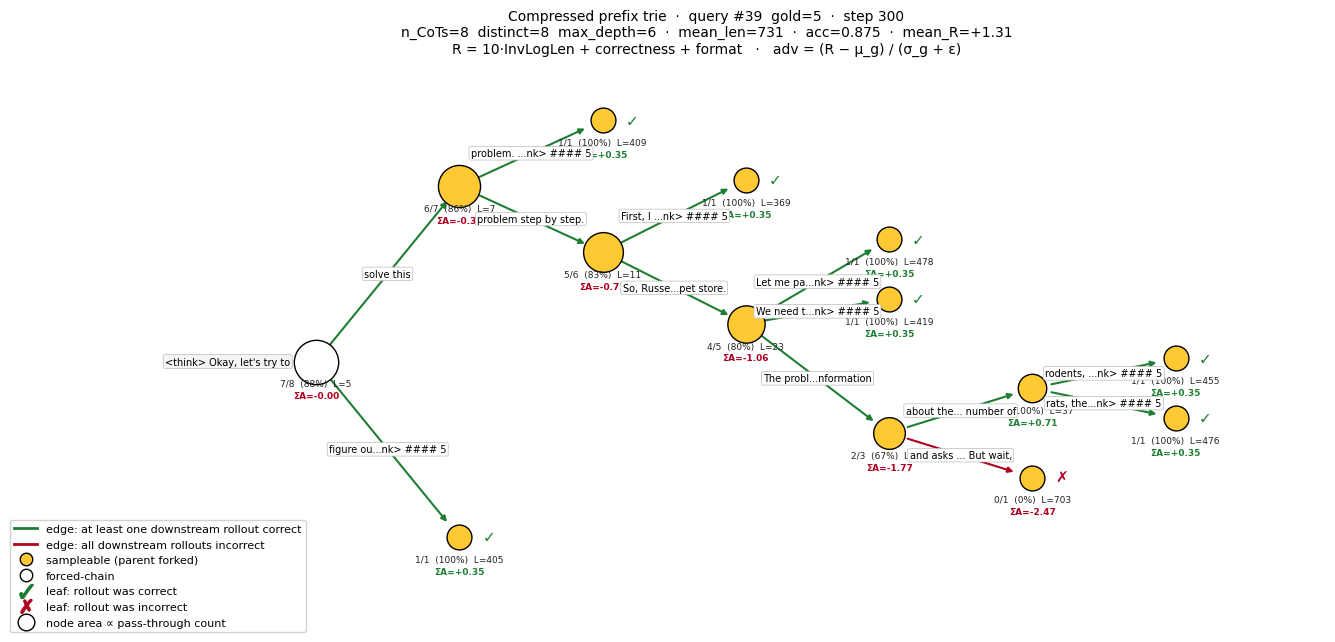

In [5]:
# Visualize prefix trie on a specific (step, query) — minimal kernel.
#
# `idx` here = query_id (the idx-th question, with all NUM_GEN rollouts).
# Tweak `global_step` and `idx` to inspect any (step, query) pair.

import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("/Users/fangyuanyu/Implementation/arl")))
from src.prefix_trie import (
    tokenize,
    build_trie_with_correctness,
    draw_compressed_trie,
    legend_handles,
    compute_grpo_advantages,
)

# Reward = 10 * InvLogLength + correctness + format. Advantage is GRPO-style
# group-normalized within each (global_step, query_id) batch of N rollouts.
df = compute_grpo_advantages(df, inv_length_weight=0.0)

global_step = 300
idx = 39

sub = df[(df.global_step == global_step) & (df.query_id == idx)]
assert len(sub) > 0, f"no rollouts for global_step={global_step}, idx={idx}"

trie = build_trie_with_correctness(
    zip(sub["completion"].map(tokenize).tolist(),
        sub["correct"].tolist(),
        sub["advantage"].tolist())
)

fig, ax = plt.subplots(figsize=(13.5, 6.5))
n_layers, n_leaves, max_depth = draw_compressed_trie(ax, trie)

gold = sub.iloc[0]["gold_answer"]
n_cots = len(sub)
n_distinct = len(set(sub["completion"].tolist()))
mean_len = sub["n_cot_tokens"].mean()
acc = sub["correct"].mean()
mean_r = sub["reward"].mean()
ax.set_title(
    f"Compressed prefix trie  ·  query #{idx}  gold={gold}  ·  step {global_step}\n"
    f"n_CoTs={n_cots}  distinct={n_distinct}  max_depth={max_depth}  "
    f"·  mean_len={mean_len:.0f}  ·  acc={acc:.3f}  ·  mean_R={mean_r:+.2f}\n"
    f"R = 10·InvLogLen + correctness + format   ·   adv = (R − μ_g) / (σ_g + ε)",
    fontsize=10,
)

fig.legend(handles=legend_handles(), loc="lower left", fontsize=8,
           framealpha=0.9, bbox_to_anchor=(0.01, 0.01))
fig.tight_layout(rect=(0.06, 0.05, 1.0, 1.0))
plt.show()

In [6]:
# Interactive HTML version — dropdowns for query index + step, full-prefix hover.
from src.prefix_trie import build_interactive_overlay_html

out_path = build_interactive_overlay_html(
    df,
    output_path="trie_overlay.html",
    query_ids=sorted(df.query_id.unique().tolist()),
)
print(f"Wrote {out_path}. Open it in a browser.")

Wrote trie_overlay.html. Open it in a browser.


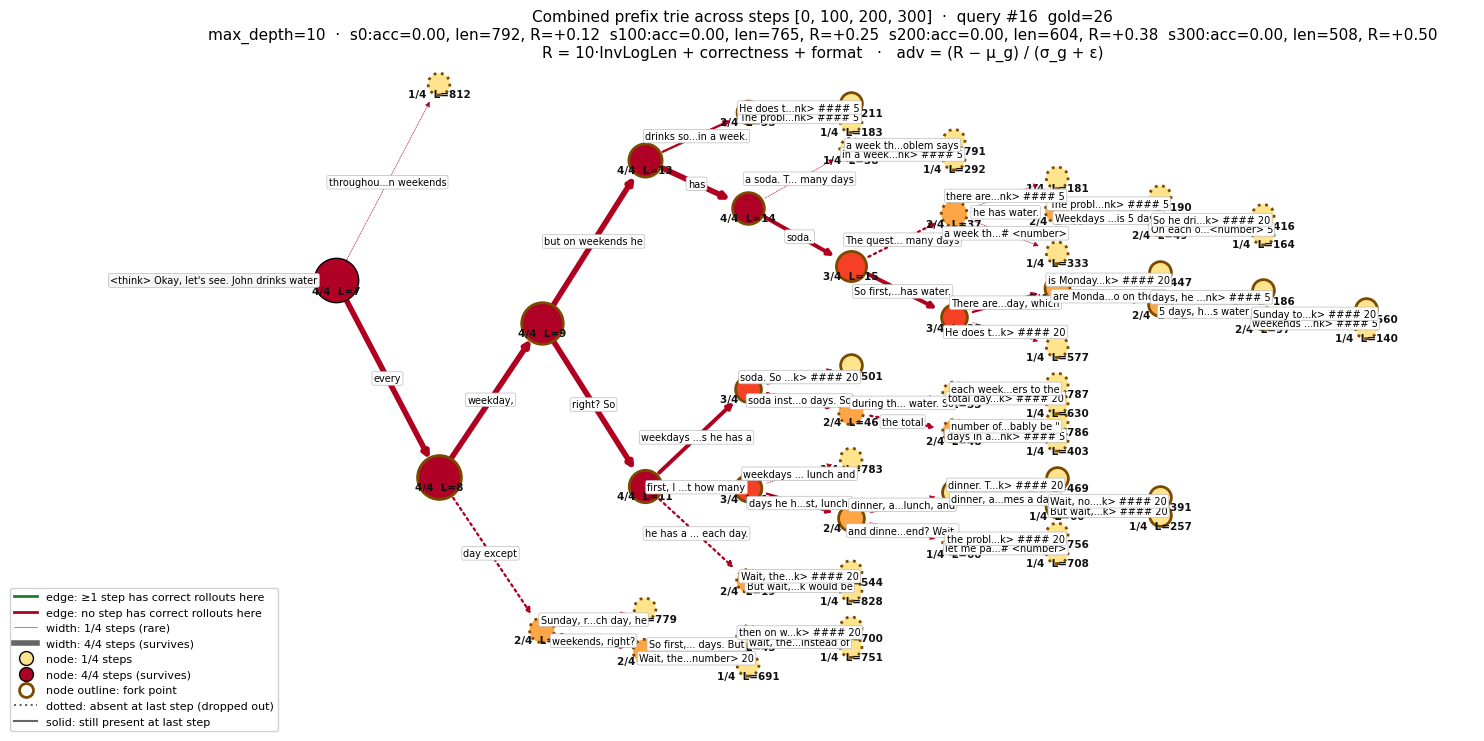

In [8]:
# Combined prefix trie for the same query across all global steps.
# Opacity encodes the global step: earlier step = more opaque, later = faded.

import matplotlib.pyplot as plt

from src.prefix_trie import (
    tokenize,
    MultiStepTrie,
    draw_overlay_trie,
    overlay_legend_handles,
)

idx = 16
steps = sorted(df.global_step.unique())

multi = MultiStepTrie()
for step in steps:
    sub_s = df[(df.global_step == step) & (df.query_id == idx)]
    for toks, c, a in zip(sub_s["completion"].map(tokenize),
                          sub_s["correct"],
                          sub_s["advantage"]):
        multi.insert(toks, c, step, advantage=a)

fig, ax = plt.subplots(figsize=(15, 7.5))
n_layers, n_leaves, max_depth = draw_overlay_trie(ax, multi, steps)

gold = df[(df.global_step == steps[0]) & (df.query_id == idx)].iloc[0]["gold_answer"]
acc_by_step = {
    s: df[(df.global_step == s) & (df.query_id == idx)]["correct"].mean()
    for s in steps
}
mean_len_by_step = {
    s: df[(df.global_step == s) & (df.query_id == idx)]["n_cot_tokens"].mean()
    for s in steps
}
mean_r_by_step = {
    s: df[(df.global_step == s) & (df.query_id == idx)]["reward"].mean()
    for s in steps
}
acc_str = "  ".join(
    f"s{s}:acc={acc_by_step[s]:.2f}, len={mean_len_by_step[s]:.0f}, R={mean_r_by_step[s]:+.2f}"
    for s in steps
)
ax.set_title(
    f"Combined prefix trie across steps {steps}  ·  query #{idx}  gold={gold}\n"
    f"max_depth={max_depth}  ·  {acc_str}\n"
    f"R = 10·InvLogLen + correctness + format   ·   adv = (R − μ_g) / (σ_g + ε)",
    fontsize=11,
)

fig.legend(handles=overlay_legend_handles(steps), loc="lower left", fontsize=8,
           framealpha=0.9, bbox_to_anchor=(0.01, 0.01))
fig.tight_layout(rect=(0.06, 0.06, 1.0, 1.0))
plt.show()

Total queries: 1303
Regressed (acc s0>=0.75, s200<=0.25): 2
Improved  (acc s0<=0.25, s200>=0.75): 9
Fully lost  (acc s0>=0.75, s200==0): 0

Length compression (len_ratio = mean_len_s200 / mean_len_s0):
  regressed  n=   2   mean len_ratio = 0.986   median = 0.986   std = 0.297
  improved   n=   9   mean len_ratio = 0.810   median = 0.836   std = 0.095
  stable     n= 910   mean len_ratio = 0.848   median = 0.850   std = 0.111
  all        n=1303   mean len_ratio = 0.842   median = 0.845   std = 0.132

regressed vs improved len_ratio: Welch t=0.83, p=0.555  (small improved sample, take with a grain of salt)


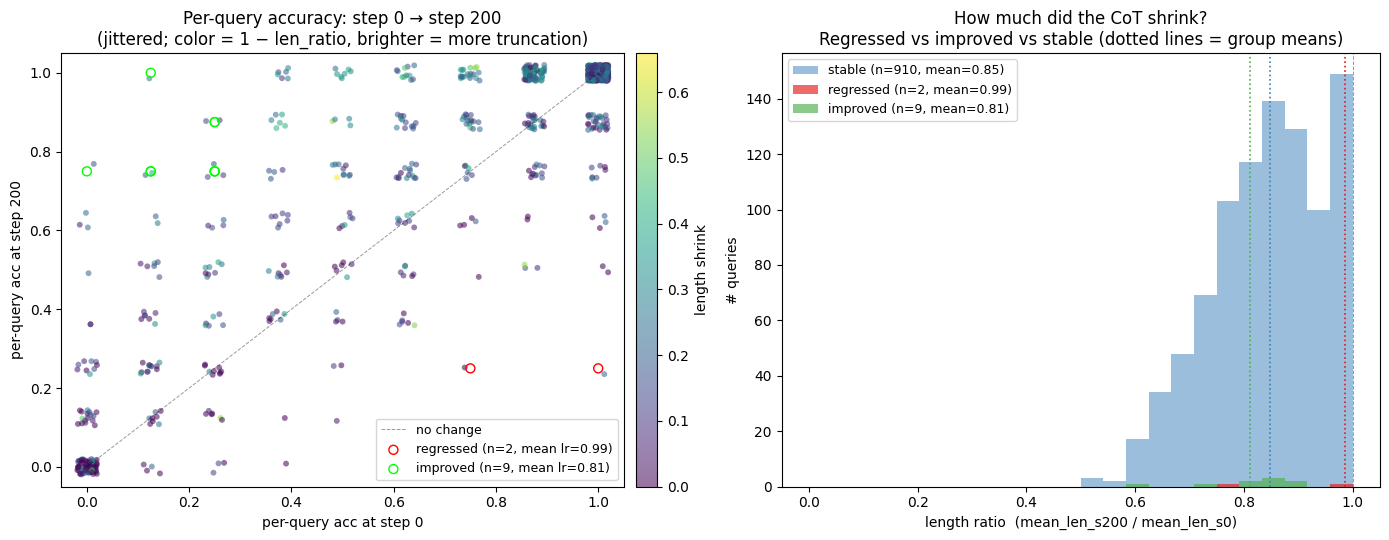


Top 10 most-regressed queries (acc dropped most, length shrank most):
          acc_s0  acc_s200  mean_len_s0  mean_len_s200  acc_drop  len_ratio
query_id                                                                   
1117        1.00      0.25      525.875        408.125      0.75      0.776
889         0.75      0.25      466.375        557.750      0.50      1.196


In [9]:
# Regression analysis: which queries went from correct (step 0) to wrong (step 200)?
#
# Per-query accuracy = mean(correct) over the 8 rollouts at that step.
# A query "regressed" if acc dropped substantially from s0 -> s200.

import matplotlib.pyplot as plt
import numpy as np

S_EARLY, S_LATE = 0, 200

per_q = (
    df[df.global_step.isin([S_EARLY, S_LATE])]
    .groupby(["global_step", "query_id"])
    .agg(acc=("correct", "mean"),
         mean_len=("n_cot_tokens", "mean"),
         gold=("gold_answer", "first"))
    .reset_index()
)
piv = per_q.pivot(index="query_id", columns="global_step",
                  values=["acc", "mean_len"])
piv.columns = [f"{a}_s{b}" for a, b in piv.columns]
piv["acc_drop"] = piv[f"acc_s{S_EARLY}"] - piv[f"acc_s{S_LATE}"]
piv["len_ratio"] = piv[f"mean_len_s{S_LATE}"] / piv[f"mean_len_s{S_EARLY}"].replace(0, np.nan)

# "Regressed": correct at s0 (acc>=0.75) and wrong at s200 (acc<=0.25).
regressed = piv[(piv[f"acc_s{S_EARLY}"] >= 0.75) & (piv[f"acc_s{S_LATE}"] <= 0.25)]
fully_lost = piv[(piv[f"acc_s{S_EARLY}"] >= 0.75) & (piv[f"acc_s{S_LATE}"] == 0.0)]
# "Improved": symmetric — wrong at s0 (acc<=0.25) and correct at s200 (acc>=0.75).
improved = piv[(piv[f"acc_s{S_EARLY}"] <= 0.25) & (piv[f"acc_s{S_LATE}"] >= 0.75)]
stable = piv[piv["acc_drop"].abs() < 0.1]

def _summarize(name, group):
    r = group["len_ratio"].dropna()
    print(f"  {name:<10s} n={len(group):>4d}   "
          f"mean len_ratio = {r.mean():.3f}   "
          f"median = {r.median():.3f}   "
          f"std = {r.std():.3f}")

print(f"Total queries: {len(piv)}")
print(f"Regressed (acc s{S_EARLY}>=0.75, s{S_LATE}<=0.25): {len(regressed)}")
print(f"Improved  (acc s{S_EARLY}<=0.25, s{S_LATE}>=0.75): {len(improved)}")
print(f"Fully lost  (acc s{S_EARLY}>=0.75, s{S_LATE}==0): {len(fully_lost)}")

print("\nLength compression (len_ratio = mean_len_s200 / mean_len_s0):")
_summarize("regressed", regressed)
_summarize("improved",  improved)
_summarize("stable",    stable)
_summarize("all",       piv)

# Are regressed truly compressed harder than improved? Quick Welch t-test.
from scipy import stats as _st
t, p = _st.ttest_ind(regressed["len_ratio"].dropna(),
                     improved["len_ratio"].dropna(), equal_var=False)
print(f"\nregressed vs improved len_ratio: Welch t={t:.2f}, p={p:.3g}  "
      f"(small improved sample, take with a grain of salt)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- (a) acc scatter: step 0 vs step 200, point color = how much length shrank ---
ax = axes[0]
shrink = 1 - piv["len_ratio"].clip(0, 1)  # 0 = same length, 1 = collapsed to nothing
sc = ax.scatter(
    piv[f"acc_s{S_EARLY}"] + np.random.uniform(-0.02, 0.02, len(piv)),
    piv[f"acc_s{S_LATE}"] + np.random.uniform(-0.02, 0.02, len(piv)),
    c=shrink, cmap="viridis", s=18, alpha=0.55, edgecolor="none",
)
ax.plot([0, 1], [0, 1], "k--", lw=0.7, alpha=0.4, label="no change")
ax.scatter(regressed[f"acc_s{S_EARLY}"], regressed[f"acc_s{S_LATE}"],
           facecolor="none", edgecolor="red", s=42, lw=1.0,
           label=f"regressed (n={len(regressed)}, mean lr={regressed['len_ratio'].mean():.2f})")
ax.scatter(improved[f"acc_s{S_EARLY}"], improved[f"acc_s{S_LATE}"],
           facecolor="none", edgecolor="lime", s=42, lw=1.0,
           label=f"improved (n={len(improved)}, mean lr={improved['len_ratio'].mean():.2f})")
ax.set_xlabel(f"per-query acc at step {S_EARLY}")
ax.set_ylabel(f"per-query acc at step {S_LATE}")
ax.set_title(f"Per-query accuracy: step {S_EARLY} → step {S_LATE}\n"
             f"(jittered; color = 1 − len_ratio, brighter = more truncation)")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right", fontsize=9)
fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label="length shrink")

# --- (b) length distribution: regressed vs improved vs stable ---
ax = axes[1]
bins = np.linspace(0, 1, 25)
ax.hist(stable["len_ratio"].dropna().clip(0, 1), bins=bins, alpha=0.5,
        label=f"stable (n={len(stable)}, mean={stable['len_ratio'].mean():.2f})",
        color="#377eb8")
ax.hist(regressed["len_ratio"].dropna().clip(0, 1), bins=bins, alpha=0.65,
        label=f"regressed (n={len(regressed)}, mean={regressed['len_ratio'].mean():.2f})",
        color="#e41a1c")
ax.hist(improved["len_ratio"].dropna().clip(0, 1), bins=bins, alpha=0.65,
        label=f"improved (n={len(improved)}, mean={improved['len_ratio'].mean():.2f})",
        color="#4daf4a")
# vertical lines at group means
for g, c in [(stable, "#377eb8"), (regressed, "#e41a1c"), (improved, "#4daf4a")]:
    ax.axvline(g["len_ratio"].mean(), color=c, lw=1.2, ls=":")
ax.axvline(1.0, color="k", lw=0.7, ls="--", alpha=0.4)
ax.set_xlabel(f"length ratio  (mean_len_s{S_LATE} / mean_len_s{S_EARLY})")
ax.set_ylabel("# queries")
ax.set_title("How much did the CoT shrink?\n"
             "Regressed vs improved vs stable (dotted lines = group means)")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

# Persist the regression list for the next cell.
regressed_sorted = regressed.sort_values(
    by=[f"acc_s{S_LATE}", "acc_drop", "len_ratio"],
    ascending=[True, False, True],
)
print(f"\nTop 10 most-regressed queries (acc dropped most, length shrank most):")
print(regressed_sorted.head(10).round(3))


In [12]:
# Assumption 2. 
# prefixes with "lost keys" (zero advantage) are less likely to "survive" the training
# Observation. 
# with length regularization, all prefix got extremely low survivial rate, this test is more meaningful for GRPO baselines

Per-step stats by group:

[all]  (n_queries = 1303)
       acc  len_correct  len_wrong  len_all  n_correct  n_wrong
step                                                           
0     0.80       475.37     937.14   568.62       8319     2105
100   0.81       147.89     271.16   170.75       8491     1933
200   0.72        87.55     117.74    96.13       7461     2963
300   0.70        78.39     101.34    85.34       7267     3157

[regressed]  (n_queries = 105)
       acc  len_correct  len_wrong  len_all  n_correct  n_wrong
step                                                           
0     0.93       554.27     863.04   574.86        784       56
100   0.71       172.19     201.80   180.79        596      244
200   0.12       118.96      95.64    98.39         99      741
300   0.22        96.55      94.07    94.61        182      658

[improved]  (n_queries = 37)
       acc  len_correct  len_wrong  len_all  n_correct  n_wrong
step                                                  

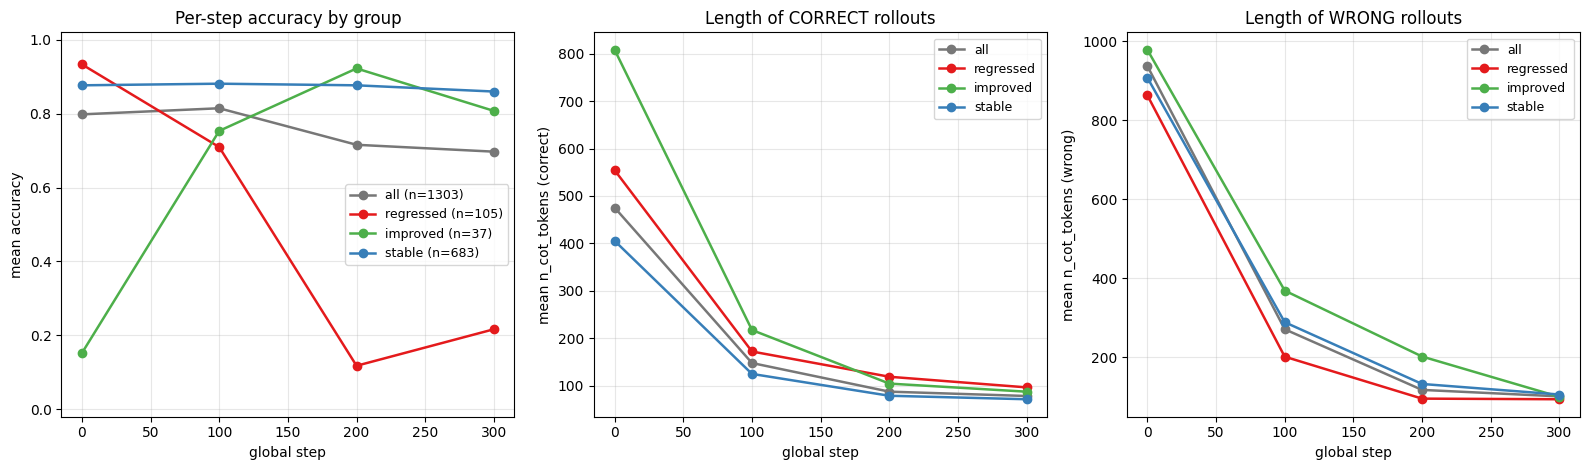

In [36]:
# Assumption 3. rollout accuracy + length dynamics explain regression.
#
# For each global step, compute per-group:
#   - mean accuracy
#   - mean length of CORRECT rollouts
#   - mean length of WRONG  rollouts
# split by group ∈ {regressed, improved, stable, all}.
#
# Question: do regressed queries show a distinctive trajectory — e.g.
# correct-rollout length collapses faster than the population, dragging
# accuracy down, while wrong rollouts stay short the whole time?

import matplotlib.pyplot as plt
import numpy as np

steps_all = sorted(df.global_step.unique())

groups = {
    "all":       piv.index,
    "regressed": regressed.index,
    "improved":  improved.index,
    "stable":    stable.index,
}
colors = {"all": "#777777", "regressed": "#e41a1c",
          "improved": "#4daf4a", "stable": "#377eb8"}

def per_step_stats(qids):
    sub = df[df.query_id.isin(qids)]
    out = []
    for s in steps_all:
        ss = sub[sub.global_step == s]
        if len(ss) == 0:
            continue
        correct_len = ss.loc[ss.correct, "n_cot_tokens"].mean()
        wrong_len   = ss.loc[~ss.correct, "n_cot_tokens"].mean()
        out.append({
            "step": s,
            "acc":  ss["correct"].mean(),
            "len_correct": correct_len,
            "len_wrong":   wrong_len,
            "len_all":     ss["n_cot_tokens"].mean(),
            "n_correct":   int(ss["correct"].sum()),
            "n_wrong":     int((~ss["correct"]).sum()),
        })
    return pd.DataFrame(out).set_index("step")

stats = {name: per_step_stats(qids) for name, qids in groups.items()}

print("Per-step stats by group:")
for name, s in stats.items():
    print(f"\n[{name}]  (n_queries = {len(groups[name])})")
    print(s.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)

# --- (a) accuracy vs step ---
ax = axes[0]
for name, s in stats.items():
    ax.plot(s.index, s["acc"], "o-", color=colors[name], lw=1.8,
            label=f"{name} (n={len(groups[name])})")
ax.set_xlabel("global step"); ax.set_ylabel("mean accuracy")
ax.set_title("Per-step accuracy by group")
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# --- (b) length of CORRECT rollouts ---
ax = axes[1]
for name, s in stats.items():
    ax.plot(s.index, s["len_correct"], "o-", color=colors[name], lw=1.8,
            label=f"{name}")
ax.set_xlabel("global step"); ax.set_ylabel("mean n_cot_tokens (correct)")
ax.set_title("Length of CORRECT rollouts")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# --- (c) length of WRONG rollouts ---
ax = axes[2]
for name, s in stats.items():
    ax.plot(s.index, s["len_wrong"], "o-", color=colors[name], lw=1.8,
            label=f"{name}")
ax.set_xlabel("global step"); ax.set_ylabel("mean n_cot_tokens (wrong)")
ax.set_title("Length of WRONG rollouts")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# fig.suptitle(
#     "Trajectory of accuracy & rollout length across training steps\n"
#     "Regressed queries: do correct rollouts shrink faster than wrong ones?",
#     fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
# another row of 3 sub-figure
# 2nd & 3rd: counts of special n-grams for correct & incorrect rollouts

Mean special-n-grams per rollout by group:

[all]  (n_queries = 1303)
       acc  mk_all  mk_correct  mk_wrong  n_correct  n_wrong
step                                                        
0     0.80    6.01        4.52     11.88       8319     2105
100   0.81    0.58        0.32      1.75       8491     1933
200   0.72    0.14        0.07      0.31       7461     2963
300   0.70    0.09        0.04      0.20       7267     3157

[regressed]  (n_queries = 105)
       acc  mk_all  mk_correct  mk_wrong  n_correct  n_wrong
step                                                        
0     0.93    5.51        5.21      9.75        784       56
100   0.71    0.58        0.46      0.86        596      244
200   0.12    0.13        0.33      0.10         99      741
300   0.22    0.18        0.11      0.20        182      658

[improved]  (n_queries = 37)
       acc  mk_all  mk_correct  mk_wrong  n_correct  n_wrong
step                                                        
0     0.15   1

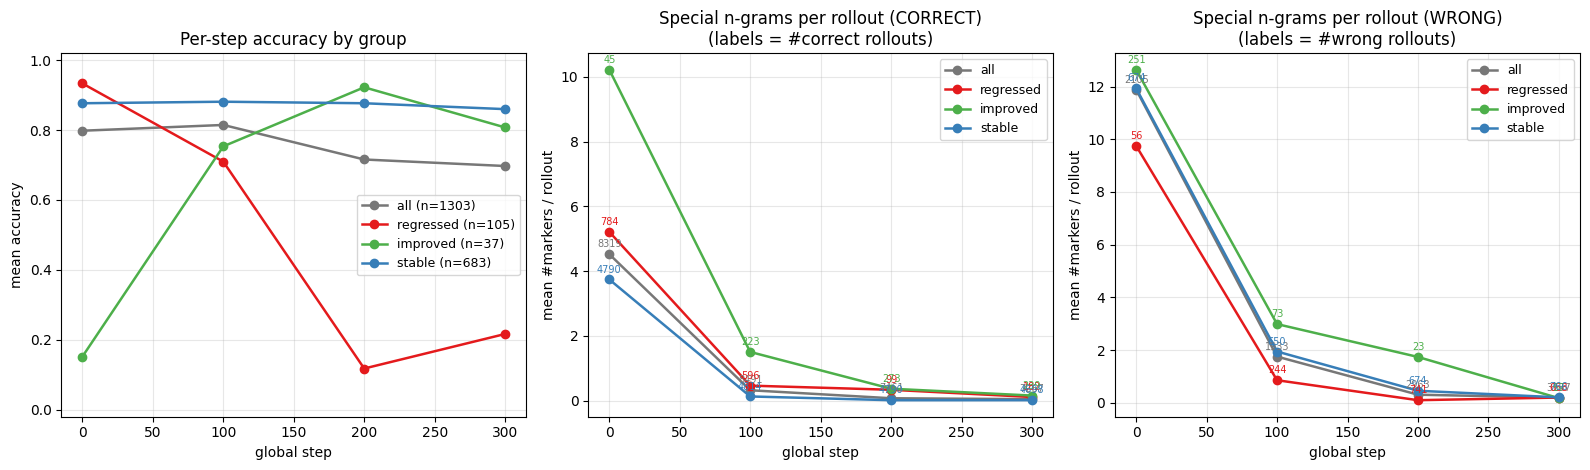

In [35]:
# Another row (mirrors the Assumption-3 row above): special-n-gram counts.
# (a) accuracy  (b) CORRECT  (c) WRONG  — (b)/(c) = mean #exploration markers
# per rollout, by group, across steps; (a) = accuracy for context.
#
# Special n-grams = exploration / backtracking / self-verification phrases
# ("wait", "let me check again", "make sure I didn't make a mistake", ...).
# The hypothesis (Explanation 4): wrong rollouts carry MORE of these than
# correct ones for stable/improved queries, but ~the same for regressed.
#
# This is the CANONICAL definition of the marker set — later cells reuse `pat`,
# df["n_markers"] and df["markers_per1k"] computed here.

import re
import matplotlib.pyplot as plt

EXPLORE_PATTERNS = [
    # backtracking / hesitation
    r"\bwait\b", r"hold on(?: a (?:sec|second|moment))?", r"\bhmm+\b",
    r"on second thought", r"scratch that", r"\binstead\b", r"\bactually\b",
    r"alternativ\w*", r"no,?\s*wait", r"oh wait", r"but wait",
    # explicit re-do / re-think
    r"let me redo", r"let me try again", r"let me reconsider", r"let me reexamine",
    r"let me re-?read", r"let me recompute", r"let me recalculate",
    r"let me re-?evaluate", r"think again", r"recompute", r"recalculate",
    # self-verification / checking
    r"let me check(?: again)?", r"check again", r"checking again",
    r"let me verify", r"let me confirm", r"let me make sure", r"let me double[- ]?check",
    r"double[- ]?check", r"re-?check",
    r"make sure", r"to be sure", r"just to be safe", r"to make sure",
    # error / correctness self-doubt
    r"that'?s (?:not right|wrong|incorrect)", r"is that (?:right|correct)",
    r"i made (?:a|an) (?:mistake|error)",
    r"did i (?:make|do) (?:a|an|the)?\s*(?:mistake|error)",
    r"\bmistake\b", r"\berror\b",
]
pat = re.compile("|".join(EXPLORE_PATTERNS), re.IGNORECASE)

df["n_markers"]     = df["completion"].map(lambda t: len(pat.findall(t)))
df["markers_per1k"] = df["n_markers"] / df["n_cot_tokens"] * 1000

# per-step marker counts by group, split by correctness (mirrors per_step_stats)
def per_step_ngrams(qids):
    sub = df[df.query_id.isin(qids)]
    out = []
    for s in steps_all:
        ss = sub[sub.global_step == s]
        if len(ss) == 0:
            continue
        out.append({
            "step": s,
            "acc":        ss["correct"].mean(),
            "mk_all":     ss["n_markers"].mean(),
            "mk_correct": ss.loc[ss.correct, "n_markers"].mean(),
            "mk_wrong":   ss.loc[~ss.correct, "n_markers"].mean(),
            "n_correct":  int(ss["correct"].sum()),
            "n_wrong":    int((~ss["correct"]).sum()),
        })
    return pd.DataFrame(out).set_index("step")

ngram_stats = {name: per_step_ngrams(qids) for name, qids in groups.items()}

print("Mean special-n-grams per rollout by group:")
for name, s in ngram_stats.items():
    print(f"\n[{name}]  (n_queries = {len(groups[name])})")
    print(s.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)

# --- (a) accuracy vs step (context) ---
ax = axes[0]
for name, s in ngram_stats.items():
    ax.plot(s.index, s["acc"], "o-", color=colors[name], lw=1.8,
            label=f"{name} (n={len(groups[name])})")
ax.set_xlabel("global step"); ax.set_ylabel("mean accuracy")
ax.set_title("Per-step accuracy by group")
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# --- (b) CORRECT rollouts ---
ax = axes[1]
for name, s in ngram_stats.items():
    ax.plot(s.index, s["mk_correct"], "o-", color=colors[name], lw=1.8, label=name)
    for st in s.index:
        ax.annotate(str(s.loc[st, "n_correct"]), (st, s.loc[st, "mk_correct"]),
                    textcoords="offset points", xytext=(0, 5), ha="center",
                    fontsize=7, color=colors[name])
ax.set_xlabel("global step"); ax.set_ylabel("mean #markers / rollout")
ax.set_title("Special n-grams per rollout (CORRECT)\n(labels = #correct rollouts)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# --- (c) WRONG rollouts ---
ax = axes[2]
for name, s in ngram_stats.items():
    ax.plot(s.index, s["mk_wrong"], "o-", color=colors[name], lw=1.8, label=name)
    for st in s.index:
        ax.annotate(str(s.loc[st, "n_wrong"]), (st, s.loc[st, "mk_wrong"]),
                    textcoords="offset points", xytext=(0, 5), ha="center",
                    fontsize=7, color=colors[name])
ax.set_xlabel("global step"); ax.set_ylabel("mean #markers / rollout")
ax.set_title("Special n-grams per rollout (WRONG)\n(labels = #wrong rollouts)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# fig.suptitle(
#     "Per-step accuracy + special-n-gram (exploration-marker) counts by group\n"
#     "CORRECT vs WRONG — do wrong rollouts carry more search/verify n-grams?",
#     fontsize=11, y=1.04)
fig.tight_layout()
plt.show()


Length gap (len_wrong - len_correct), with rollout counts:
  all        step 0: 937 - 475 =    462   (correct=8319, wrong=2105)
  regressed  step 0: 863 - 554 =    309   (correct=784, wrong=56)
  improved   step 0: 978 - 808 =    170   (correct=45, wrong=251)
  stable     step 0: 908 - 405 =    502   (correct=4790, wrong=674)


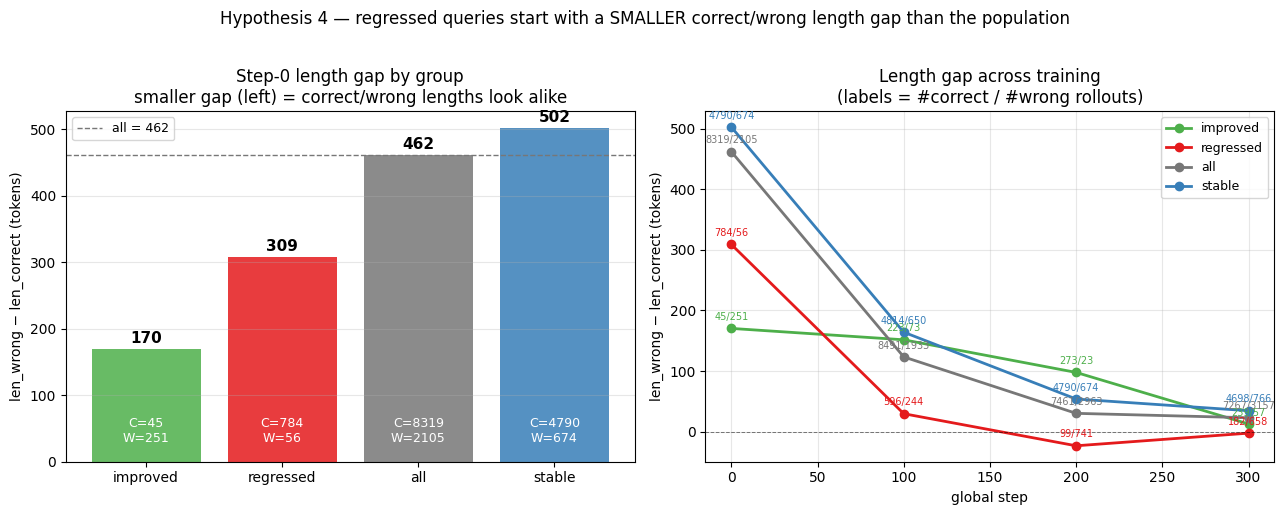


Verdict: regressed gap (309) < all (462) < stable (502) => SUPPORTS the hypothesis.
Nuance: improved is even smaller (170) — so a small step-0 gap marks UNSTABLE queries (movers in either direction),
        while STABLE queries have the largest gap. Stable correct rollouts are clearly shorter than their wrong ones from the start.
Caveat: the regressed step-0 gap rests on only 56 wrong rollouts (vs 784 correct).


In [24]:
# Hypothesis 4:
# at step 0, queries with smaller gap between correct & incorrect rollout length
# are more likely to regress.
#
# Just read the step-0 gap = len_wrong - len_correct straight from the per-group
# `stats` table built in the previous cell. No fancy stats needed — the group
# means already tell the story:
#   regressed: 863 - 554 = 309   <   all: 937 - 475 = 462
#
# Each point is annotated with the supporting rollout counts (C=#correct,
# W=#wrong) so thin samples are visible — e.g. the regressed step-0 gap rests on
# only 56 wrong rollouts, so treat it with care.

import matplotlib.pyplot as plt

gap = {name: s["len_wrong"] - s["len_correct"] for name, s in stats.items()}  # Series over steps

print(f"Length gap (len_wrong - len_correct), with rollout counts:")
for name in ["all", "regressed", "improved", "stable"]:
    s0 = stats[name].loc[S_EARLY]
    print(f"  {name:<10s} step {S_EARLY}: {s0['len_wrong']:.0f} - {s0['len_correct']:.0f} = "
          f"{s0['len_wrong'] - s0['len_correct']:6.0f}   "
          f"(correct={int(s0['n_correct'])}, wrong={int(s0['n_wrong'])})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) step-0 gap by group — the direct comparison
ax = axes[0]
order = ["improved", "regressed", "all", "stable"]
vals = [gap[n].loc[S_EARLY] for n in order]
bars = ax.bar(order, vals, color=[colors[n] for n in order], alpha=0.85)
ax.axhline(gap["all"].loc[S_EARLY], color="#777", ls="--", lw=1,
           label=f"all = {gap['all'].loc[S_EARLY]:.0f}")
for b, v, n in zip(bars, vals, order):
    s0 = stats[n].loc[S_EARLY]
    ax.annotate(f"{v:.0f}", (b.get_x() + b.get_width()/2, v),
                textcoords="offset points", xytext=(0, 4), ha="center",
                fontsize=11, fontweight="bold")
    # rollout counts inside the bar
    ax.annotate(f"C={int(s0['n_correct'])}\nW={int(s0['n_wrong'])}",
                (b.get_x() + b.get_width()/2, 0),
                textcoords="offset points", xytext=(0, 14), ha="center",
                fontsize=9, color="white")
ax.set_ylabel("len_wrong − len_correct (tokens)")
ax.set_title(f"Step-{S_EARLY} length gap by group\n"
             "smaller gap (left) = correct/wrong lengths look alike")
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=9)

# (b) gap across all steps, one line per group — annotate C/W at every point
ax = axes[1]
for name in order:
    g = gap[name]
    ax.plot(g.index, g.values, "o-", color=colors[name], lw=2, label=name)
    for step in g.index:
        row = stats[name].loc[step]
        ax.annotate(f"{int(row['n_correct'])}/{int(row['n_wrong'])}",
                    (step, g.loc[step]), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=7, color=colors[name])
ax.axhline(0, color="k", lw=0.7, ls="--", alpha=0.5)
ax.set_xlabel("global step"); ax.set_ylabel("len_wrong − len_correct (tokens)")
ax.set_title("Length gap across training\n(labels = #correct / #wrong rollouts)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig.suptitle("Hypothesis 4 — regressed queries start with a SMALLER correct/wrong "
             "length gap than the population", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# verdict
g_reg, g_all, g_stable = (gap["regressed"].loc[S_EARLY], gap["all"].loc[S_EARLY],
                          gap["stable"].loc[S_EARLY])
print(f"\nVerdict: regressed gap ({g_reg:.0f}) < all ({g_all:.0f}) < stable ({g_stable:.0f}) "
      f"=> SUPPORTS the hypothesis.")
print(f"Nuance: improved is even smaller ({gap['improved'].loc[S_EARLY]:.0f}) — so a small "
      f"step-{S_EARLY} gap marks UNSTABLE queries (movers in either direction),\n"
      f"        while STABLE queries have the largest gap. Stable correct rollouts are "
      f"clearly shorter than their wrong ones from the start.")
print(f"Caveat: the regressed step-{S_EARLY} gap rests on only "
      f"{int(stats['regressed'].loc[S_EARLY]['n_wrong'])} wrong rollouts "
      f"(vs {int(stats['regressed'].loc[S_EARLY]['n_correct'])} correct).")


Most common exploration markers (whole dataset):
  wait                   32050
  let me check again     6060
  but wait               5600
  let me check           5224
  hmm                    5076
  alternatively          2584
  let me make sure       2581
  to make sure           1991
  let me double-check    1928
  mistake                1742
  actually               676
  think again            616
  let me verify          489
  is that right          478
  i made a mistake       475

Exploration-marker gap (wrong − correct):

[all]
  step   0: count  C=4.52 W=11.88 (gap=+7.36) | per1k  C=9.20 W=12.45 (gap=+3.26)  [n_c=8319, n_w=2105]
  step 100: count  C=0.32 W=1.75 (gap=+1.43) | per1k  C=1.00 W=3.30 (gap=+2.30)  [n_c=8491, n_w=1933]
  step 200: count  C=0.07 W=0.31 (gap=+0.24) | per1k  C=0.26 W=0.89 (gap=+0.63)  [n_c=7461, n_w=2963]
  step 300: count  C=0.04 W=0.20 (gap=+0.16) | per1k  C=0.18 W=0.64 (gap=+0.46)  [n_c=7267, n_w=3157]

[regressed]
  step   0: count  C=5.21 W=9.75

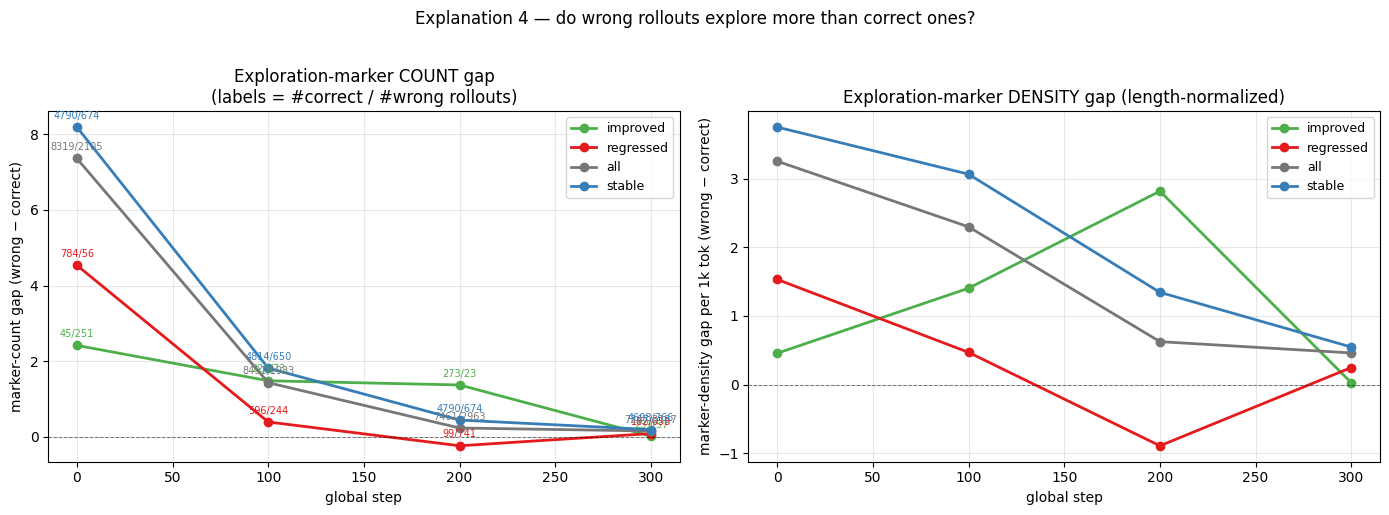


### STABLE / avg  | step 0 | query #992 | gold=90
    density gap (wrong−correct) = +14.62 markers/1k tok  (n_correct=5, n_wrong=3)
------------------------------------------------------------------------------
[CORRECT rollout] len=331 tok, markers=3
<think>
Okay, let's see. Karen wants to get both a manicure and a pedicure, and then add nail art on each of her fingers. Let me break this down step by step.

First, the basic manicure starts at $35 and the pedicure starts at $40. The salon offers a 20% discount if she gets both. So I need to calculate the total before the discount and then apply the 20% off.

⟦WAIT⟧, the discount is on both services together. So the original total without the discount would be $35 + $40 = $75. Then 20% off of $75. Let me calculate that. 20% of 75 is 0.20 * 75 = $15. So the discounted price for both is $75 - $15 = $60.

Now, she also wants to add nail art on each of her fingers. Each finger has 1 nail, so 10 fingers. The cost is $3 per nail. So 10 nails

In [31]:
# Validate Explanation 4 via exploration-marker analysis + CoT case study.
#
# Claim: wrong rollouts explore/backtrack/verify more than correct ones
# ("wait...", "hold on", "let me check again", "make sure I didn't make a
# mistake"...) BECAUSE the model can tell it is unsure and keeps searching =>
# wrong rollouts run longer. This correct/wrong *exploration gap* should exist
# for stable/avg queries and for improved queries (esp. late), but be ~absent
# for regressed queries (the model can't tell right from wrong, so both look
# alike — hence the small length gap from Hypothesis 4).
#
# The marker set `pat` and df["n_markers"]/["markers_per1k"] are defined in the
# "special n-gram counts per rollout" cell above (single source of truth).

import textwrap
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

if "pat" not in globals() or "n_markers" not in df.columns:
    raise RuntimeError("Run the 'special n-gram counts per rollout' cell first "
                       "(it defines `pat` and df['n_markers']).")

allm = Counter(m.lower() for t in df["completion"] for m in pat.findall(t))
print("Most common exploration markers (whole dataset):")
for m, c in allm.most_common(15):
    print(f"  {m:<22s} {c}")

# --- per-(group, step) marker stats split by correctness --------------------
def per_step_markers(qids):
    sub = df[df.query_id.isin(qids)]
    out = []
    for s in steps_all:
        ss = sub[sub.global_step == s]
        if len(ss) == 0:
            continue
        c, w = ss[ss.correct], ss[~ss.correct]
        out.append(dict(
            step=s,
            cnt_correct=c["n_markers"].mean(),   cnt_wrong=w["n_markers"].mean(),
            den_correct=c["markers_per1k"].mean(), den_wrong=w["markers_per1k"].mean(),
            n_correct=len(c), n_wrong=len(w),
        ))
    return pd.DataFrame(out).set_index("step")

mstats = {n: per_step_markers(g) for n, g in groups.items()}

print("\nExploration-marker gap (wrong − correct):")
for name in ["all", "regressed", "improved", "stable"]:
    m = mstats[name]
    print(f"\n[{name}]")
    for s in m.index:
        r = m.loc[s]
        print(f"  step {s:>3}: count  C={r['cnt_correct']:.2f} W={r['cnt_wrong']:.2f} "
              f"(gap={r['cnt_wrong']-r['cnt_correct']:+.2f}) | "
              f"per1k  C={r['den_correct']:.2f} W={r['den_wrong']:.2f} "
              f"(gap={r['den_wrong']-r['den_correct']:+.2f})  "
              f"[n_c={int(r['n_correct'])}, n_w={int(r['n_wrong'])}]")

# =====================  VISUALIZATION  ======================================
order = ["improved", "regressed", "all", "stable"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) marker COUNT gap across steps (parallels the length gap in cell 12)
ax = axes[0]
for name in order:
    m = mstats[name]
    gap = m["cnt_wrong"] - m["cnt_correct"]
    ax.plot(m.index, gap, "o-", color=colors[name], lw=2, label=name)
    for s in m.index:
        ax.annotate(f"{int(m.loc[s,'n_correct'])}/{int(m.loc[s,'n_wrong'])}",
                    (s, gap.loc[s]), textcoords="offset points", xytext=(0, 6),
                    ha="center", fontsize=7, color=colors[name])
ax.axhline(0, color="k", lw=0.7, ls="--", alpha=0.5)
ax.set_xlabel("global step"); ax.set_ylabel("marker-count gap (wrong − correct)")
ax.set_title("Exploration-marker COUNT gap\n(labels = #correct / #wrong rollouts)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# (b) marker DENSITY gap (per 1k tokens) — controls for length
ax = axes[1]
for name in order:
    m = mstats[name]
    gap = m["den_wrong"] - m["den_correct"]
    ax.plot(m.index, gap, "o-", color=colors[name], lw=2, label=name)
ax.axhline(0, color="k", lw=0.7, ls="--", alpha=0.5)
ax.set_xlabel("global step"); ax.set_ylabel("marker-density gap per 1k tok (wrong − correct)")
ax.set_title("Exploration-marker DENSITY gap (length-normalized)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig.suptitle("Explanation 4 — do wrong rollouts explore more than correct ones?",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# =====================  CoT CASE STUDY  =====================================
def _trim(text, max_chars=1600):
    hl = pat.sub(lambda m: f"⟦{m.group(0).upper()}⟧", text)
    return hl if len(hl) <= max_chars else hl[:max_chars] + "  …[truncated]"

def case_study(qids, step, label, want_gap=True):
    """Pick a query (both outcomes at `step`) and print a correct vs wrong CoT.
    want_gap=True -> pick the query with the LARGEST wrong−correct density gap
    (to illustrate the behavior); False -> gap closest to 0 (regressed control)."""
    sub = df[(df.global_step == step) & (df.query_id.isin(qids))]
    cand = []
    for qid, g in sub.groupby("query_id"):
        c, w = g[g.correct], g[~g.correct]
        if len(c) == 0 or len(w) == 0:
            continue
        gapv = w["markers_per1k"].mean() - c["markers_per1k"].mean()
        cand.append((gapv, qid, c, w))
    if not cand:
        print(f"\n### {label}: no query with BOTH outcomes at step {step}.")
        return
    cand.sort(key=lambda x: x[0], reverse=want_gap)
    gapv, qid, c, w = cand[0]
    # representative correct = shortest (early termination); wrong = most markers
    crow = c.loc[c["n_cot_tokens"].idxmin()]
    wrow = w.loc[w["n_markers"].idxmax()]
    print("\n" + "=" * 78)
    print(f"### {label}  | step {step} | query #{qid} | gold={crow['gold_answer']}")
    print(f"    density gap (wrong−correct) = {gapv:+.2f} markers/1k tok  "
          f"(n_correct={len(c)}, n_wrong={len(w)})")
    print("-" * 78)
    print(f"[CORRECT rollout] len={int(crow['n_cot_tokens'])} tok, "
          f"markers={int(crow['n_markers'])}")
    print(_trim(crow["completion"]))
    print("-" * 78)
    print(f"[WRONG rollout]   len={int(wrow['n_cot_tokens'])} tok, "
          f"markers={int(wrow['n_markers'])}")
    print(_trim(wrow["completion"]))

# stable/avg & improved-late should show wrong>correct exploration;
# regressed should show ~no gap (control).
case_study(stable.index,   S_EARLY, "STABLE / avg",      want_gap=True)
case_study(improved.index, S_LATE,  "IMPROVED (late)",   want_gap=True)
case_study(regressed.index, S_EARLY, "REGRESSED (control)", want_gap=False)

# --- verdict -----------------------------------------------------------------
def gap_at(name, step, col_w, col_c):
    m = mstats[name]
    return (m.loc[step, col_w] - m.loc[step, col_c]) if step in m.index else float("nan")

print("\n" + "=" * 60)
print("VERDICT (marker-density gap per 1k tok, wrong − correct):")
print(f"  stable    @s{S_EARLY}: {gap_at('stable', S_EARLY,'den_wrong','den_correct'):+.2f}")
print(f"  improved  @s{S_LATE}: {gap_at('improved', S_LATE,'den_wrong','den_correct'):+.2f}")
print(f"  regressed @s{S_EARLY}: {gap_at('regressed', S_EARLY,'den_wrong','den_correct'):+.2f}")
print("Hypothesis predicts: stable/improved gaps POSITIVE (wrong explores more),")
print("regressed gap ~0 (model can't distinguish right from wrong).")


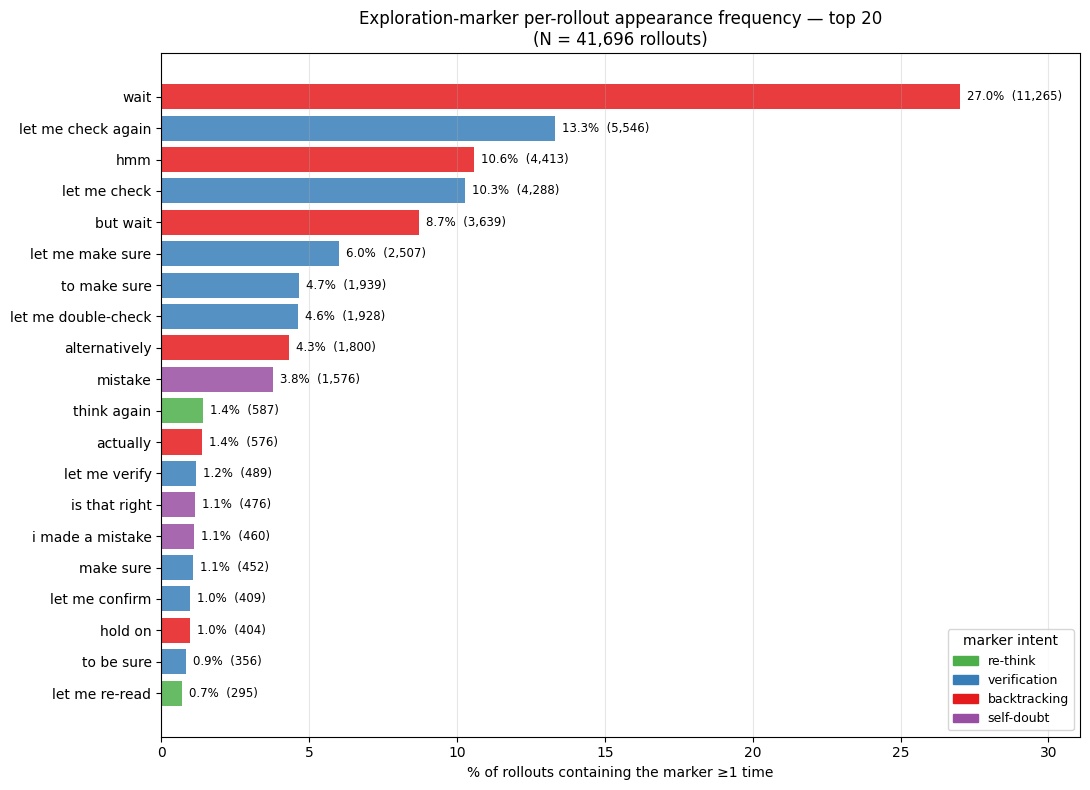

Rollouts containing ANY exploration marker: 30.5%

Per-rollout appearance frequency by intent family:
  backtracking    28.4%  (11,838 rollouts)
  verification    25.1%  (10,463 rollouts)
  self-doubt       6.5%  (2,702 rollouts)
  re-think         2.4%  (1,007 rollouts)


In [32]:
# Per-rollout APPEARANCE frequency: fraction of rollouts containing each marker
# at least once (vs raw occurrence counts above). Reuses `pat` and `family`.
import matplotlib.pyplot as plt
from collections import Counter

present = Counter()
for t in df["completion"]:
    for m in set(x.lower() for x in pat.findall(t)):  # set => count each rollout once
        present[m] += 1
N = len(df)

TOP_N = 20
items  = present.most_common(TOP_N)
labels = [m for m, _ in items][::-1]
freqs  = [present[m] / N * 100 for m in labels]
bar_colors = [family(m)[1] for m in labels]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(range(len(labels)), freqs, color=bar_colors, alpha=0.85)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("% of rollouts containing the marker ≥1 time")
ax.set_title(f"Exploration-marker per-rollout appearance frequency — top {TOP_N}\n"
             f"(N = {N:,} rollouts)")
ax.grid(alpha=0.3, axis="x")
for b, m in zip(bars, labels):
    cnt = present[m]
    ax.annotate(f"{cnt/N*100:.1f}%  ({cnt:,})",
                (b.get_width(), b.get_y() + b.get_height()/2),
                textcoords="offset points", xytext=(5, 0), va="center", fontsize=8.5)

from matplotlib.patches import Patch
seen = {}
for m in labels:
    n, c = family(m); seen[n] = c
ax.legend(handles=[Patch(color=c, label=n) for n, c in seen.items()],
          title="marker intent", loc="lower right", fontsize=9)
ax.margins(x=0.15)
fig.tight_layout()
plt.show()

# any-marker presence + per-family presence
any_marker = (df["n_markers"] > 0).mean()
print(f"Rollouts containing ANY exploration marker: {any_marker:.1%}")
print("\nPer-rollout appearance frequency by intent family:")
# a rollout 'has' a family if any of that family's markers appear in it
fam_present = Counter()
for t in df["completion"]:
    fams = set(family(x.lower())[0] for x in pat.findall(t))
    for f in fams:
        fam_present[f] += 1
for name, c in sorted(fam_present.items(), key=lambda x: -x[1]):
    print(f"  {name:<14s} {c/N*100:5.1f}%  ({c:,} rollouts)")


In [ ]:
# Hypothesis

In [5]:
# actually it'd be better if we can build an interactive .html file, so that when my cursor move to the text box, I can literally see the full text content, instead of head ... tail summary. 